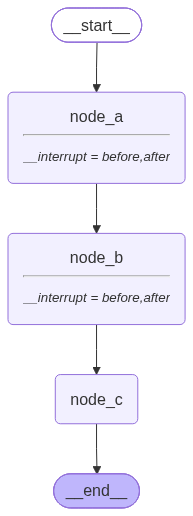

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_a(node_a<hr/><small><em>__interrupt = before,after</em></small>)
	node_b(node_b<hr/><small><em>__interrupt = before,after</em></small>)
	node_c(node_c)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_a;
	node_a --> node_b;
	node_b --> node_c;
	node_c --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [1]:
from typing import TypedDict


from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph,START,END
from loguru import logger

#1. 声明状态
class OverAllState(TypedDict):
    final_res:str

#2. 声明节点
def node_a(state:OverAllState)->OverAllState:
    logger.info("node_a被执行")
    return {
        "final_res":"node_a运行的中间结果"
    }

def node_b(state:OverAllState)->OverAllState:
    logger.info("node_b被执行")
    return {
        "final_res":"node_b运行的中间结果"
    }

def node_c(state:OverAllState)->OverAllState:
    logger.info("node_c被执行")
    return {
        "final_res":"node_c运行的结果"
    }

#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a",node_a)
builder.add_node("node_b",node_b)
builder.add_node("node_c",node_c)

builder.add_edge(START,"node_a")
builder.add_edge("node_a","node_b")
builder.add_edge("node_b","node_c")
builder.add_edge("node_c",END)

#4. 检查点后端存储
checkpointer = InMemorySaver()
graph = builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["node_a","node_b"],
    interrupt_after=["node_a","node_b"]
)

from IPython.display import display
display(graph)
raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)
config = {"configurable":{"thread_id":"123"}}


In [6]:
# 第一次运行
print("\n========== 第 1 次 invoke ==========")

res = graph.invoke(
    {"final_res": "初始结果"},
    config=config
)

print("当前 State：")
print(res)


========== 第 1 次 invoke ==========
当前 State：
{'final_res': '初始结果'}


In [7]:
# 第二次运行
print("\n========== 第 2 次 invoke ==========")

res = graph.invoke(
    None,
    config=config
)

print("当前 State：")
print(res)

2026-08-14 18:24:00.963 | INFO     | __main__:node_a:14 - node_a被执行



========== 第 2 次 invoke ==========
当前 State：
{'final_res': 'node_a运行的中间结果'}


In [8]:
# 第三次运行
print("\n========== 第 3 次 invoke ==========")

res = graph.invoke(
    None,
    config=config
)

print("当前 State：")
print(res)

2026-08-14 18:24:06.815 | INFO     | __main__:node_b:20 - node_b被执行



========== 第 3 次 invoke ==========
当前 State：
{'final_res': 'node_b运行的中间结果'}


In [9]:
# 第四次运行
print("\n========== 第 4 次 invoke ==========")

res = graph.invoke(
    None,
    config=config
)

print("当前 State：")
print(res)

2026-08-14 18:24:14.933 | INFO     | __main__:node_c:26 - node_c被执行



========== 第 4 次 invoke ==========
当前 State：
{'final_res': 'node_c运行的结果'}


In [10]:
# 第五次运行
print("\n========== 第 5 次 invoke ==========")

res = graph.invoke(
    None,
    config=config
)

print("当前 State：")
print(res)


========== 第 5 次 invoke ==========
当前 State：
{'final_res': 'node_c运行的结果'}


In [11]:
# ------------------ 5. 执行测试 ------------------

# 初始输入
initial_input = {"final_res": "初始状态"}

print("=== 1. 第一次调用 invoke ===")
# 因为设置了 interrupt_before=["node_a"]，图会在执行 node_a 之前立刻暂停
res1 = graph.invoke(initial_input, config)
print("invoke 返回值:", res1)

# 查看当前图的状态
state = graph.get_state(config)
print("👉 当前节点状态:")
print("   Next 待执行节点:", state.next)  # 应为 ('node_a',)
print("   Values 当前数据:", state.values)

print("\n" + "=" * 40 + "\n")

print("=== 2. 继续执行（触发 node_a 运行，随后被 interrupt_after 拦截）===")
# 传入 None 继续运行
res2 = graph.invoke(None, config)

state = graph.get_state(config)
print("👉 当前节点状态:")
print("   Next 待执行节点:", state.next)  # node_a 已执行完毕，下一个是 node_b，但注意此时停在 node_a 之后/node_b 之前
print("   Values 当前数据:", state.values)  # 此时包含 node_a 更新的 final_res

print("\n" + "=" * 40 + "\n")

print("=== 3. 循环推进，直到流程全部结束 ===")
step = 3
while state.next:
    print(f"--- 推进步骤 {step} ---")
    graph.invoke(None, config)
    state = graph.get_state(config)
    print("   Next 待执行节点:", state.next)
    print("   Values 当前数据:", state.values)
    step += 1

print("\n全流程执行完毕！")

2026-08-14 18:31:24.731 | INFO     | __main__:node_a:14 - node_a被执行
2026-08-14 18:31:24.733 | INFO     | __main__:node_b:20 - node_b被执行
2026-08-14 18:31:24.735 | INFO     | __main__:node_c:26 - node_c被执行


=== 1. 第一次调用 invoke ===
invoke 返回值: {'final_res': '初始状态'}
👉 当前节点状态:
   Next 待执行节点: ('node_a',)
   Values 当前数据: {'final_res': '初始状态'}


=== 2. 继续执行（触发 node_a 运行，随后被 interrupt_after 拦截）===
👉 当前节点状态:
   Next 待执行节点: ('node_b',)
   Values 当前数据: {'final_res': 'node_a运行的中间结果'}


=== 3. 循环推进，直到流程全部结束 ===
--- 推进步骤 3 ---
   Next 待执行节点: ('node_c',)
   Values 当前数据: {'final_res': 'node_b运行的中间结果'}
--- 推进步骤 4 ---
   Next 待执行节点: ()
   Values 当前数据: {'final_res': 'node_c运行的结果'}

全流程执行完毕！


运行上述测试代码后，你会看到类似如下的过程：

首次 invoke：由于配置了 interrupt_before=["node_a"]，日志中不会打印 "node_a被执行"，state.next 显示为 ('node_a',)，表示当前正停在 node_a 的门外。

第二次 invoke(None, config)：

node_a 正式执行，日志打印 "node_a被执行"。

由于配置了 interrupt_after=["node_a"]，在 node_a 执行完后图再次暂停。

state.values 中已经更新了 "node_a运行的中间结果"。

随后的 invoke(None, config)：因为又碰上了 interrupt_before=["node_b"] 和 interrupt_after=["node_b"]，每次调用只推进半步，直到跳出 while 循环（state.next 为空元组 ()），表示图完整运行结束。

In [12]:
# ==================== 测试中断与恢复逻辑 ====================

# 初始化输入数据
initial_input = {"final_res": "初始状态"}

print("=== 1. 第一次启动图执行 ===")
# 使用 stream 运行，观察中断过程
for event in graph.stream(initial_input, config=config):
    print("事件输出:", event)

# 检查当前图的状态
state = graph.get_state(config)
print("\n[状态检查 1]")
print(f"下一个待执行节点 (next): {state.next}")
print(f"当前 State 数据: {state.values}")


print("\n=== 2. 第一次恢复 (Resume): 继续执行 node_a ===")
# 传入 None 作为 input，通知 LangGraph 从暂停点继续运行
for event in graph.stream(None, config=config):
    print("事件输出:", event)

# 再次检查状态
state = graph.get_state(config)
print("\n[状态检查 2]")
print(f"下一个待执行节点 (next): {state.next}")
print(f"当前 State 数据: {state.values}")


print("\n=== 3. 第二次恢复 (Resume): 触发 node_b 的中断并继续，直到图运行结束 ===")
while state.next:
    print(f"\n--- 触发 Resume，下一个节点是: {state.next} ---")
    for event in graph.stream(None, config=config):
        print("事件输出:", event)
    state = graph.get_state(config)

print("\n=== 图运行完全结束 ===")
print(f"最终 State 结果: {state.values}")


2026-08-14 18:32:53.486 | INFO     | __main__:node_a:14 - node_a被执行
2026-08-14 18:32:53.488 | INFO     | __main__:node_b:20 - node_b被执行
2026-08-14 18:32:53.490 | INFO     | __main__:node_c:26 - node_c被执行


=== 1. 第一次启动图执行 ===
事件输出: {'__interrupt__': ()}

[状态检查 1]
下一个待执行节点 (next): ('node_a',)
当前 State 数据: {'final_res': '初始状态'}

=== 2. 第一次恢复 (Resume): 继续执行 node_a ===
事件输出: {'node_a': {'final_res': 'node_a运行的中间结果'}}
事件输出: {'__interrupt__': ()}

[状态检查 2]
下一个待执行节点 (next): ('node_b',)
当前 State 数据: {'final_res': 'node_a运行的中间结果'}

=== 3. 第二次恢复 (Resume): 触发 node_b 的中断并继续，直到图运行结束 ===

--- 触发 Resume，下一个节点是: ('node_b',) ---
事件输出: {'node_b': {'final_res': 'node_b运行的中间结果'}}
事件输出: {'__interrupt__': ()}

--- 触发 Resume，下一个节点是: ('node_c',) ---
事件输出: {'node_c': {'final_res': 'node_c运行的结果'}}

=== 图运行完全结束 ===
最终 State 结果: {'final_res': 'node_c运行的结果'}


运行上述测试代码后，你会看到类似如下的执行日志：

首次运行 (stream(initial_input))：

因为设置了 interrupt_before=["node_a"]，图在刚要进入 node_a 时便直接暂停。

logger.info("node_a被执行") 不会被打印。

state.next 的值为 ('node_a',)。

第一次 Resume (stream(None))：

node_a 开始执行（输出 node_a被执行）。

但因为设置了 interrupt_after=["node_a"]（同时也有 interrupt_before=["node_b"]），node_a 执行完后图再次暂停。

state.next 的值为 ('node_b',)，state.values 更新为 {'final_res': 'node_a运行的中间结果'}。

后续 Resume：

依次完成 node_b 的中断与恢复，最后无阻碍地运行完 node_c 并到达 END。

当 state.next 变为空元组 () 时，说明图已彻底执行完毕。

提示： 恢复执行的核心在于传入相同的 config={"configurable": {"thread_id": "123"}} 并将输入参数置为 None（graph.stream(None, config)）。Checkpoint 会自动记住当前中断的位置。